In [26]:
print("hi")

hi


In [27]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field

from langchain_core.messages import SystemMessage, HumanMessage

In [28]:
load_dotenv()

True

In [29]:
class structured_output(BaseModel):
    evaluate: Literal['approved','needs_improvment'] =Field(description="Final evaluation result.")
    feedback: str =Field(description="feedback for the tweet.")

In [30]:
class tweet_state(TypedDict):
    topic:str
    tweet:str
    evaluate:Literal['approved','needs_improvment']
    feedback: str
    iteration:int
    max_iteration:int


In [ ]:
# model_1= ChatGroq(
#     model="openai/gpt-oss-20b",
#     api_key=os.environ["GROQ_API_KEY"],
# ).bind_tools([], tool_choice="none")

# model=model_1.with_structured_output(structured_output)

# model_2= ChatGroq(
#     model="openai/gpt-oss-120b",
#     api_key=os.environ["GROQ_API_KEY"],
# ).bind_tools([], tool_choice="none")

In [31]:
model_1=ChatGroq(model_name='llama-3.3-70b-versatile')
model=model_1.with_structured_output(structured_output)
model_2=ChatGroq(model_name="openai/gpt-oss-120b")

In [13]:
model.invoke('Stress, Responsibilities, Hopes, Breakdowns, Emotions, Regrets, Heartbeats, and Breaths.')

structured_output(evaluate='approved', feedback='Here’s a tweet that weaves together those themes:\n\n> Stress, responsibilities, hopes, breakdowns, emotions, regrets, heartbeats, breaths – the rhythm of our human story. 🌪️💖 #LifeInMotion')

In [53]:
graph=StateGraph(tweet_state)

In [54]:
def tweet_generator(state:tweet_state):
    topic=state['topic']
    iteration=0
        # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 200 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
            ]
    tweet=model_1.invoke(messages).content
    #tweet='Stress, Responsibilities, Hopes, Breakdowns, Emotions, Regrets, Heartbeats, and Breaths.'
    max_iteration=5
    return {'tweet':tweet,'iteration':iteration,'max_iteration':max_iteration}

def tweet_evaluator(state:tweet_state):
    tweet=state['tweet']
    i=state['iteration']
    # if i==0:
    #     prompt=f'{tweet}'
    #     evaluate=model.invoke(prompt)
    #     return {'evaluate':evaluate}
    # else:
    #     feedback=state['feedback']
    #     prompt=f'{tweet},{feedback}'
    #     evaluate=model.invoke(prompt)
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 200 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvment"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]
    tweet=model.invoke(messages)
    return {'evaluate':tweet.evaluate,'feedback':tweet.feedback}


def check_condition(state:tweet_state):
    if state['evaluate']=='needs_improvment' and state['iteration']<=state['max_iteration']:
        return 'needs_improvment'
    else:
        return 'approved'

def tweet_optimizer(state:tweet_state):
    tweet=state['tweet']
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 200 characters.
    """)
        ]
    new_tweet=model_2.invoke(messages).content
    i=state['iteration']
    i+=1
    return {'tweet':new_tweet,'iteration':i}



In [55]:
graph.add_node('tweet_generator',tweet_generator)
graph.add_node('tweet_evaluator',tweet_evaluator)
graph.add_node('tweet_optimizer',tweet_optimizer)

graph.add_edge(START,'tweet_generator')
graph.add_edge('tweet_generator','tweet_evaluator')
graph.add_conditional_edges('tweet_evaluator',check_condition,{'approved':END,'needs_improvment':'tweet_optimizer'})
graph.add_edge('tweet_optimizer','tweet_evaluator')


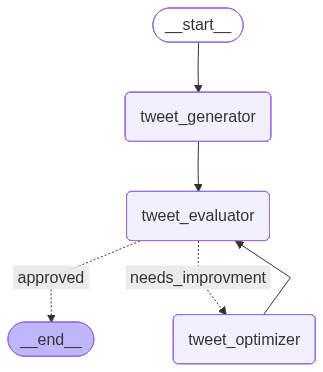

In [56]:
workflow=graph.compile()
workflow

In [57]:
initial_state={'topic':'mr.bean'}

output=workflow.invoke(initial_state)
output

{'topic': 'mr.bean',
 'tweet': '"Mr Bean\'s life is just me as an adult, but with better suits"',
 'evaluate': 'approved',
 'feedback': "This tweet is a winner. It's short, sharp, and scroll-stopping, making it punchy. The comparison between Mr Bean's life and adulthood is original and humorous, putting a smile on the reader's face. The tweet is well-formed, under 280 characters, and doesn't follow a traditional setup-punchline format. The addition of 'but with better suits' adds a nice touch of humor and unexpected twist, making it relatable and increasing its virality potential. Overall, this tweet checks all the right boxes and has the potential to resonate with a wide audience.",
 'iteration': 0,
 'max_iteration': 5}

In [58]:
state=tweet_state(**output)
state

{'topic': 'mr.bean',
 'tweet': '"Mr Bean\'s life is just me as an adult, but with better suits"',
 'evaluate': 'approved',
 'feedback': "This tweet is a winner. It's short, sharp, and scroll-stopping, making it punchy. The comparison between Mr Bean's life and adulthood is original and humorous, putting a smile on the reader's face. The tweet is well-formed, under 280 characters, and doesn't follow a traditional setup-punchline format. The addition of 'but with better suits' adds a nice touch of humor and unexpected twist, making it relatable and increasing its virality potential. Overall, this tweet checks all the right boxes and has the potential to resonate with a wide audience.",
 'iteration': 0,
 'max_iteration': 5}

In [59]:
state['tweet']

'"Mr Bean\'s life is just me as an adult, but with better suits"'

In [60]:
initial_state={'topic':'ahiromira'}

output=workflow.invoke(initial_state)
output

{'topic': 'ahiromira',
 'tweet': '"just spent 10 mins searching for ahiromira and i think it\'s just my wifi password"',
 'evaluate': 'approved',
 'feedback': "This tweet is a masterclass in brevity and surprise. The unexpected twist on 'ahiro mira' being the wifi password is both original and humorous, making it scroll-stopping and potentially viral. The format is well-executed, under 280 characters, and doesn't rely on tired joke structures. The language is simple yet effective, and the relatability of struggling with wifi passwords adds to the humor. Overall, this tweet checks all the boxes for a great tweet, with its only potential weakness being that some users might not find it funny, but that's subjective.",
 'iteration': 0,
 'max_iteration': 5}

In [61]:
initial_state={'topic':'jsdfsdjfgu'}

output=workflow.invoke(initial_state)
output

{'topic': 'jsdfsdjfgu',
 'tweet': 'My cat just walked across the keyboard and turned my password into “jsdfsdjfgu.” Now I’m locked out and he’s giving me that smug “I’m helping” stare. 🐱💻 #CatProblems',
 'evaluate': 'approved',
 'feedback': "This tweet is a masterclass in humor and originality. The scenario of a cat walking across the keyboard and changing the password is relatable and fresh, and the added detail of the cat's smug stare adds to the comedic effect. The tweet is also well-formatted, concise, and under 280 characters, making it scroll-stopping and easy to read. The use of relevant hashtags like #CatProblems increases its virality potential. Overall, this tweet has a great balance of humor, originality, and punchiness, making it a strong candidate for retweets and shares.",
 'iteration': 1,
 'max_iteration': 5}

In [42]:
state['iteration']

0